# Двойна задача за разпознаване на плочки

**Въведение:** Тази задача включва анализ на смесени изображения, създадени от двойки изображения от набора данни STL-10, с цел да се предскажат както изходното изображение, така и оригиналната позиция на всяка отделна плочка.

## I. Общ преглед на проблема
Задачата използва изображения, създадени чрез комбиниране на две различни изображения от STL-10 с различни етикети на класове. Всяко оригинално изображение се преоразмерява до 96x96 пиксела и се разделя на мрежа от 3x3 плочки (всяка с размер 32x32 пиксела). Всички 18 плочки от двете изображения след това се разбъркват на случаен принцип и се подреждат в мрежа от 3x6, създавайки смесени изображения за анализ.

## II. Набор от данни
Наборът от данни се състои от 5000 смесени изображения за обучение и 500 смесени изображения за валидация. Всяко смесено изображение съдържа 18 плочки от две различни изходни изображения от STL-10. Данните са разделени, като изображенията и етикетите са подготвени за незабавна употреба. Размерите на файловете са оптимизирани за бързо обучение на средно мощен хардуер или безплатни графични процесори (GPU) в Colab.

## III. Задача
Проектирайте и имплементирайте модел на невронна мрежа с PyTorch, който да анализира смесените изображения и да предсказва две характеристики за всяка плочка. Специфичните изисквания са следните:

1. **Класификация на източника**: Определете от кое оригинално изображение произхожда плочката:
  - Етикет 0: Плочка от първото изходно (source) изображение (по-светлото изображение).
  - Етикет 1: Плочка от второто изходно (source) изображение (по-тъмното изображение).

2. **Класификация на позицията**: Идентифицирайте оригиналната позиция на плочката в мрежата 3x3:
  - Етикети 0–8: Съответстващи на позициите в оригиналната мрежа 3x3.

**Изисквания към модела:**
- Именувайте класа на модела `TileClassifier()`. Използването на други имена може да доведе до проблеми при оценяването.
- Включете поне 3 конволюционни слоя (nn.Conv2d) със съответните слоеве за batch normalization и pooling.
- Включете поне 2 напълно свързани слоя (nn.Linear) за всяка от двете класификационни "глави" (classification heads).
- - Използвайте подходящи активационни функции, например nn.ReLU.
- Моделът трябва да приема входни тензори с размерност [B×18, 3, 32, 32], където B е размерът на бача (batch size).
- Моделът трябва да връща два набора от логити (logits): source_logits с размерност [B×18, 2] и position_logits с размерност [B×18, 9].
- Функцията на загуба (loss function), оптимизаторът и скоростта на обучение (learning rate) могат да бъдат избрани свободно.

## IV. Оценка
Производителността се измерва чрез метрики за точност (accuracy) за двете класификационни задачи. Оценката се извършва върху тест сет от 5000 разбъркани изображения:
- **Точност на източника (Source Accuracy):**: `correct_source_predictions / total_tiles`
- **Точност на позицията (Position Accuracy)**: `correct_position_predictions / total_tiles`

## V. Изисквания за предаване
За финалното предаване архивирайте следните 2 файла:
- Файл с предсказанията във формат JSON (`predictions.json`). Файлът трябва да съдържа предсказанията за всички плочки от тестовия набор в последователен ред. Формат на файла:
```json
[
    {"source": 0, "position": 5},
    {"source": 1, "position": 2},
    ...
]

- Тази тетрадка, преименувана по подходящ начин.



In [1]:
!pip install gdown
!gdown 1_cm2IzYrohgqnXEWBEXO1UtYBW2UqFdZ

Downloading...
From (original): https://drive.google.com/uc?id=1_cm2IzYrohgqnXEWBEXO1UtYBW2UqFdZ
From (redirected): https://drive.google.com/uc?id=1_cm2IzYrohgqnXEWBEXO1UtYBW2UqFdZ&confirm=t&uuid=757f1858-f58b-4b43-8c22-1e4b1d020c66
To: /content/mixed_dataset_competition.zip
100% 278M/278M [00:04<00:00, 57.1MB/s]


In [2]:
! unzip mixed_dataset_competition.zip

Streaming output truncated to the last 5000 lines.
  inflating: mixed_dataset/train/labels/2783.npy  
  inflating: mixed_dataset/train/labels/0194.npy  
  inflating: mixed_dataset/train/labels/2973.npy  
  inflating: mixed_dataset/train/labels/0802.npy  
  inflating: mixed_dataset/train/labels/0816.npy  
  inflating: mixed_dataset/train/labels/2967.npy  
  inflating: mixed_dataset/train/labels/4325.npy  
  inflating: mixed_dataset/train/labels/2754.npy  
  inflating: mixed_dataset/train/labels/0143.npy  
  inflating: mixed_dataset/train/labels/0625.npy  
  inflating: mixed_dataset/train/labels/2032.npy  
  inflating: mixed_dataset/train/labels/4443.npy  
  inflating: mixed_dataset/train/labels/2026.npy  
  inflating: mixed_dataset/train/labels/4457.npy  
  inflating: mixed_dataset/train/labels/3338.npy  
  inflating: mixed_dataset/train/labels/0631.npy  
  inflating: mixed_dataset/train/labels/1249.npy  
  inflating: mixed_dataset/train/labels/0157.npy  
  inflating: mixed_dataset/trai

In [ ]:
########## BASELINE
# ====================================================================================================
# ЗОНА ЗА СЪСТЕЗАТЕЛИ: Променете кода под този ред като запазите интерфейсите на методите и класовете
# ====================================================================================================
# Някои идеи:
# 1. Добавете характеристики за глобален контекст, които взимат предвид връзките между всички плочки, вместо да обработвате всяка една независимо.
# 2. Експериментирайте с различни стратегии за pooling и методи за агрегиране на характеристики в мрежата.
# 3. Опитайте подходи за multi-scale извличане на характеристики, за да уловите информация на различни нива на детайлност.
# 4. Променете начина, по който характеристиките се споделят или разделят между двете класификационни задачи в рамките на архитектурата на модела.
# 5. Регулирайте дълбочината, ширината и схемите на свързване в мрежата, за да уловите по-добре йерархичната природа на визуалните признаци.


class TileClassifier(nn.Module):
    def __init__(self, kernel_size=3, num_layers=3):
        super(TileClassifier, self).__init__()

        # Дефиниране на базови CNN слоеве
        cnn_layers = []
        in_channels = 3

        # Конфигуриране на канали за всеки слой
        channels = [32, 64, 128, 256][:num_layers]

        for i, out_channels in enumerate(channels):
            cnn_layers.append(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    padding=kernel_size // 2,
                )
            )
            cnn_layers.append(nn.BatchNorm2d(out_channels))
            cnn_layers.append(nn.ReLU(inplace=True))
            cnn_layers.append(nn.MaxPool2d(2))
            in_channels = out_channels

        self.cnn = nn.Sequential(*cnn_layers)

        # Пресметни размера на изходните характеристики на база входа и pooling слоеве
        feature_size = 32 // (2**num_layers)
        if feature_size < 1:
            feature_size = 1  # Minimum feature size

        flat_features = channels[-1] * feature_size * feature_size

        # Класификатор на позицията (9 positions) - не се променя
        self.position_classifier = nn.Sequential(
            nn.Linear(flat_features, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 9)
        )
        self.source_classifier = nn.Sequential(
            nn.Linear(flat_features, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2)
        )

    def forward(self, x):
        # x shape: [B * 18, 3, 32, 32], where B is batch_size from DataLoader
        num_tiles_per_image = 18  # Fixed for this problem

        tile_cnn_features = self.cnn(x)
        flat_tile_features = torch.flatten(tile_cnn_features, 1)
        position_logits = self.position_classifier(flat_tile_features)
        source_logits = self.source_classifier(flat_tile_features)
        return source_logits, position_logits

def setup_training_components(device):
    lr = 0.001
    kernel_size = 3
    num_layers = 2

    model = TileClassifier(kernel_size=kernel_size, num_layers=num_layers).to(device)
    print("Model architecture:")
    print(model)

    criterion_source = nn.CrossEntropyLoss()
    criterion_position = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    return model, criterion_source, criterion_position, optimizer, scheduler

# ==================================================================================
# НЕ ПРОМЕНЯЙ КОДА ПОД ТОЗИ РЕД!
# ==================================================================================

In [32]:
########## BASELINE
# ====================================================================================================
# ЗОНА ЗА СЪСТЕЗАТЕЛИ: Променете кода под този ред като запазите интерфейсите на методите и класовете
# ====================================================================================================
# Някои идеи:
# 1. Добавете характеристики за глобален контекст, които взимат предвид връзките между всички плочки, вместо да обработвате всяка една независимо.
# 2. Експериментирайте с различни стратегии за pooling и методи за агрегиране на характеристики в мрежата.
# 3. Опитайте подходи за multi-scale извличане на характеристики, за да уловите информация на различни нива на детайлност.
# 4. Променете начина, по който характеристиките се споделят или разделят между двете класификационни задачи в рамките на архитектурата на модела.
# 5. Регулирайте дълбочината, ширината и схемите на свързване в мрежата, за да уловите по-добре йерархичната природа на визуалните признаци.

########## BEST
import torch.nn.functional as F
import torch.nn as nn
import torch

class TileClassifier(nn.Module):
    def __init__(self):
        super(TileClassifier, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 32->16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 16->8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),  # 8->4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(), nn.AdaptiveAvgPool2d(1),  # 4->1x1, feature vector per tile
        )
        self.feature_dim = 512  # 512*1*1 = 512

        # Attention layer for global context
        self.attention = nn.MultiheadAttention(embed_dim=self.feature_dim, num_heads=8)

        # Classification heads
        self.position_classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 9)
        )
        self.source_classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 2)
        )

    def forward(self, x):
        # x: (B*18, 3, 32, 32)
        B_tiles = x.size(0)
        features = self.cnn(x).view(B_tiles, -1)  # (B*18, feature_dim)

        B = B_tiles // 18
        features = features.view(B, 18, self.feature_dim)  # (B, 18, D)

        # Prepare for attention: (seq_len, batch, embed_dim)
        features_t = features.permute(1, 0, 2)  # (18, B, D)

        # Self-attention over tiles to get context-aware features
        attn_output, _ = self.attention(features_t, features_t, features_t)  # (18, B, D)
        attn_output = attn_output.permute(1, 0, 2)  # (B, 18, D)

        # Combine local + global context from attention
        global_context = attn_output.mean(dim=1, keepdim=True).repeat(1, 18, 1)  # (B,18,D)
        features_with_context = torch.cat([features, global_context], dim=2)  # (B,18,2D)

        # Flatten back
        features_with_context = features_with_context.view(B*18, -1)  # (B*18, 2D)

        position_logits = self.position_classifier(features_with_context)
        source_logits = self.source_classifier(features_with_context)

        return source_logits, position_logits
def setup_training_components(device):
    lr = 0.001
    kernel_size = 3
    num_layers = 2

    #model = TileClassifier(kernel_size=kernel_size, num_layers=num_layers).to(device)
    model = TileClassifier().to(device)
    print("Model architecture:")
    print(model)

    criterion_source = nn.CrossEntropyLoss()
    criterion_position = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    return model, criterion_source, criterion_position, optimizer, scheduler

# ==================================================================================
# НЕ ПРОМЕНЯЙ КОДА ПОД ТОЗИ РЕД!
# ==================================================================================

In [38]:
import torch.nn.functional as F
import torch.nn as nn
import torch
import torch.optim as optim

class TileClassifier(nn.Module):
    def __init__(self):
        super(TileClassifier, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 32->16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 16->8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),  # 8->4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(), nn.AdaptiveAvgPool2d(1),  # 4->1x1, feature vector per tile
        )
        self.feature_dim = 512  # 512*1*1 = 512

        # Attention layer for global context
        self.attention = nn.MultiheadAttention(embed_dim=self.feature_dim, num_heads=8)

        # LayerNorm layers for Transformer-style residual connections
        self.ln1 = nn.LayerNorm(self.feature_dim)
        self.ln2 = nn.LayerNorm(self.feature_dim)

        # Feed-forward block (like Transformer FFN)
        self.ff = nn.Sequential(
            nn.Linear(self.feature_dim, self.feature_dim),
            nn.ReLU(),
            nn.Linear(self.feature_dim, self.feature_dim)
        )

        # Classification heads
        self.position_classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 9)
        )
        self.source_classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 2)
        )

    def forward(self, x):
        # x: (B*18, 3, 32, 32)
        B_tiles = x.size(0)
        features = self.cnn(x).view(B_tiles, -1)  # (B*18, feature_dim)

        B = B_tiles // 18
        features = features.view(B, 18, self.feature_dim)  # (B, 18, D)

        # Prepare for attention: (seq_len, batch, embed_dim)
        features_t = features.permute(1, 0, 2)  # (18, B, D)

        # Multihead Attention with residual and LayerNorm
        attn_output, _ = self.attention(features_t, features_t, features_t)  # (18, B, D)
        x = self.ln1(features_t + attn_output)  # Residual + LayerNorm

        ff_out = self.ff(x)  # Feed-forward network
        x = self.ln2(x + ff_out)  # Residual + LayerNorm

        attn_output = x.permute(1, 0, 2)  # (B, 18, D)

        # Combine local + global context from attention
        global_context = attn_output.mean(dim=1, keepdim=True).repeat(1, 18, 1)  # (B,18,D)
        features_with_context = torch.cat([features, global_context], dim=2)  # (B,18,2D)

        # Flatten back
        features_with_context = features_with_context.view(B*18, -1)  # (B*18, 2D)

        position_logits = self.position_classifier(features_with_context)
        source_logits = self.source_classifier(features_with_context)

        return source_logits, position_logits


def setup_training_components(device):
    lr = 0.001
    #model = TileClassifier(kernel_size=kernel_size, num_layers=num_layers).to(device)
    model = TileClassifier().to(device)
    print("Model architecture:")
    print(model)

    criterion_source = nn.CrossEntropyLoss()
    criterion_position = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    return model, criterion_source, criterion_position, optimizer, scheduler


In [45]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    return device

def get_data_loaders(args):
    train_dataset = MixedSTL10Dataset(root_dir=args.data_dir, split="train")
    val_dataset = MixedSTL10Dataset(root_dir=args.data_dir, split="val")

    print(f"Training set size: {len(train_dataset)}")
    print(f"Validation set size: {len(val_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False, num_workers=4)
    return train_loader, val_loader


def train_one_epoch(model, loader, crit_source, crit_pos, optimizer, device, sw, pw):
    model.train()
    total_loss, src_correct, pos_correct, total = 0.0, 0, 0, 0

    for tiles, src_labels, pos_labels in loader:
        batch_size = tiles.size(0)
        tiles = tiles.view(-1, 3, 32, 32).to(device)
        src_labels = src_labels.view(-1).to(device)
        pos_labels = pos_labels.view(-1).to(device)

        src_logits, pos_logits = model(tiles)
        src_loss = crit_source(src_logits, src_labels)
        pos_loss = crit_pos(pos_logits, pos_labels)
        loss = sw * src_loss + pw * pos_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_size
        src_correct += (src_logits.argmax(1) == src_labels).sum().item()
        pos_correct += (pos_logits.argmax(1) == pos_labels).sum().item()
        total += src_labels.size(0)

    return {
        "loss": total_loss / len(loader.dataset),
        "source_acc": src_correct / total,
        "position_acc": pos_correct / total,
    }

def evaluate(model, loader, crit_source, crit_pos, device, sw, pw):
    model.eval()
    total_loss, src_correct, pos_correct, total = 0.0, 0, 0, 0

    with torch.no_grad():
        for tiles, src_labels, pos_labels in loader:
            batch_size = tiles.size(0)
            tiles = tiles.view(-1, 3, 32, 32).to(device)
            src_labels = src_labels.view(-1).to(device)
            pos_labels = pos_labels.view(-1).to(device)

            src_logits, pos_logits = model(tiles)
            src_loss = crit_source(src_logits, src_labels)
            pos_loss = crit_pos(pos_logits, pos_labels)
            loss = sw * src_loss + pw * pos_loss

            total_loss += loss.item() * batch_size
            src_correct += (src_logits.argmax(1) == src_labels).sum().item()
            pos_correct += (pos_logits.argmax(1) == pos_labels).sum().item()
            total += src_labels.size(0)

    return {
        "loss": total_loss / len(loader.dataset),
        "source_acc": src_correct / total,
        "position_acc": pos_correct / total,
    }


def print_epoch_summary(epoch, total_epochs, start_time, train_metrics, val_metrics):
    print(f"Epoch {epoch + 1}/{total_epochs} | Time: {time.time() - start_time:.2f}s")
    print(
        f"Train Loss: {train_metrics['loss']:.4f} | Source Acc: {train_metrics['source_acc']:.4f} | "
        f"Position Acc: {train_metrics['position_acc']:.4f}"
    )
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | Source Acc: {val_metrics['source_acc']:.4f} | "
        f"Position Acc: {val_metrics['position_acc']:.4f}"
    )

def save_model_checkpoint(model, optimizer, epoch, metrics, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": metrics["loss"],
        "val_source_acc": metrics["source_acc"],
        "val_position_acc": metrics["position_acc"],
    }, path)
    print(f"Saved new best model with validation loss: {metrics['loss']:.4f}")


def train_model(args):
    device = get_device()
    train_loader, val_loader = get_data_loaders(args)
    model, criterion_source, criterion_position, optimizer, scheduler = setup_training_components(device)

    best_val_loss = float("inf")
    os.makedirs(args.output_dir, exist_ok=True)
    best_model_path = os.path.join(args.output_dir, "best_model.pth")

    source_weight = 2.0
    position_weight = 1.0

    print("Starting training...")
    for epoch in range(args.epochs):
        start_time = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, criterion_source, criterion_position, optimizer, device, source_weight, position_weight
        )

        val_metrics = evaluate(
            model, val_loader, criterion_source, criterion_position, device, source_weight, position_weight
        )

        scheduler.step(val_metrics['loss'])

        print_epoch_summary(epoch, args.epochs, start_time, train_metrics, val_metrics)

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            save_model_checkpoint(model, optimizer, epoch, val_metrics, best_model_path)

    print(f"Training complete. Best validation loss: {best_val_loss:.4f}")
    return model

def create_submission_file(model, test_loader, device, output_path="predictions.json"):
    model.eval()
    all_predictions = []

    print("Generating predictions for the test set...")
    with torch.no_grad():
        for tiles, _ in test_loader:
            tiles = tiles.view(-1, 3, 32, 32).to(device)

            src_logits, pos_logits = model(tiles)

            src_preds = torch.argmax(src_logits, dim=1).cpu().numpy()
            pos_preds = torch.argmax(pos_logits, dim=1).cpu().numpy()

            for i in range(src_preds.shape[0]):
                all_predictions.append({
                    "source": int(src_preds[i]),
                    "position": int(pos_preds[i])
                })

    with open(output_path, 'w') as f:
        json.dump(all_predictions, f, indent=4)

    print(f"Predictions saved to {output_path}")


def visualize_mixed_and_reordered(dataset, idx):
    tiles, source_labels, position_labels = dataset[idx] # tiles shape: [18, 3, 32, 32]

    tiles_np = tiles.permute(0, 2, 3, 1).numpy() # Shape: [18, 32, 32, 3]

    scrambled_image = np.zeros((3 * 32, 6 * 32, 3), dtype=np.float32)
    for i in range(18):
        row = i // 6
        col = i % 6
        scrambled_image[row*32:(row+1)*32, col*32:(col+1)*32, :] = tiles_np[i]

    source_0_tiles = []
    source_1_tiles = []
    source_0_positions = []
    source_1_positions = []

    for i in range(18):
        if source_labels[i] == 0:
            source_0_tiles.append(tiles_np[i])
            source_0_positions.append(position_labels[i])
        else:
            source_1_tiles.append(tiles_np[i])
            source_1_positions.append(position_labels[i])

    source_0_sorted_indices = np.argsort(source_0_positions)
    source_1_sorted_indices = np.argsort(source_1_positions)

    source_0_sorted_tiles = [source_0_tiles[i] for i in source_0_sorted_indices]
    source_1_sorted_tiles = [source_1_tiles[i] for i in source_1_sorted_indices]


    reordered_image_source0 = np.zeros((3 * 32, 3 * 32, 3), dtype=np.float32)
    reordered_image_source1 = np.zeros((3 * 32, 3 * 32, 3), dtype=np.float32)

    for i in range(9):
        row = i // 3
        col = i % 3
        reordered_image_source0[row*32:(row+1)*32, col*32:(col+1)*32, :] = source_0_sorted_tiles[i]
        reordered_image_source1[row*32:(row+1)*32, col*32:(col+1)*32, :] = source_1_sorted_tiles[i]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(scrambled_image)
    axes[0].set_title("Смесено изображение")
    axes[0].axis("off")

    axes[1].imshow(reordered_image_source0)
    axes[1].set_title("Подредено изображение (Изходно 0)")
    axes[1].axis("off")

    axes[2].imshow(reordered_image_source1)
    axes[2].set_title("Подредено изображение (Изходно 1)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [46]:
ls

mixed_dataset/                 model_output/     sample_data/
mixed_dataset_competition.zip  predictions.json


In [47]:
data_dir = "./mixed_dataset"
output_dir = "./model_output"
batch_size = 8
epochs = 10
lr = 0.001

# Създаване на args обект с тези параметри
class Args:
    def __init__(self):
        self.data_dir = data_dir
        self.output_dir = output_dir
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr

args = Args()

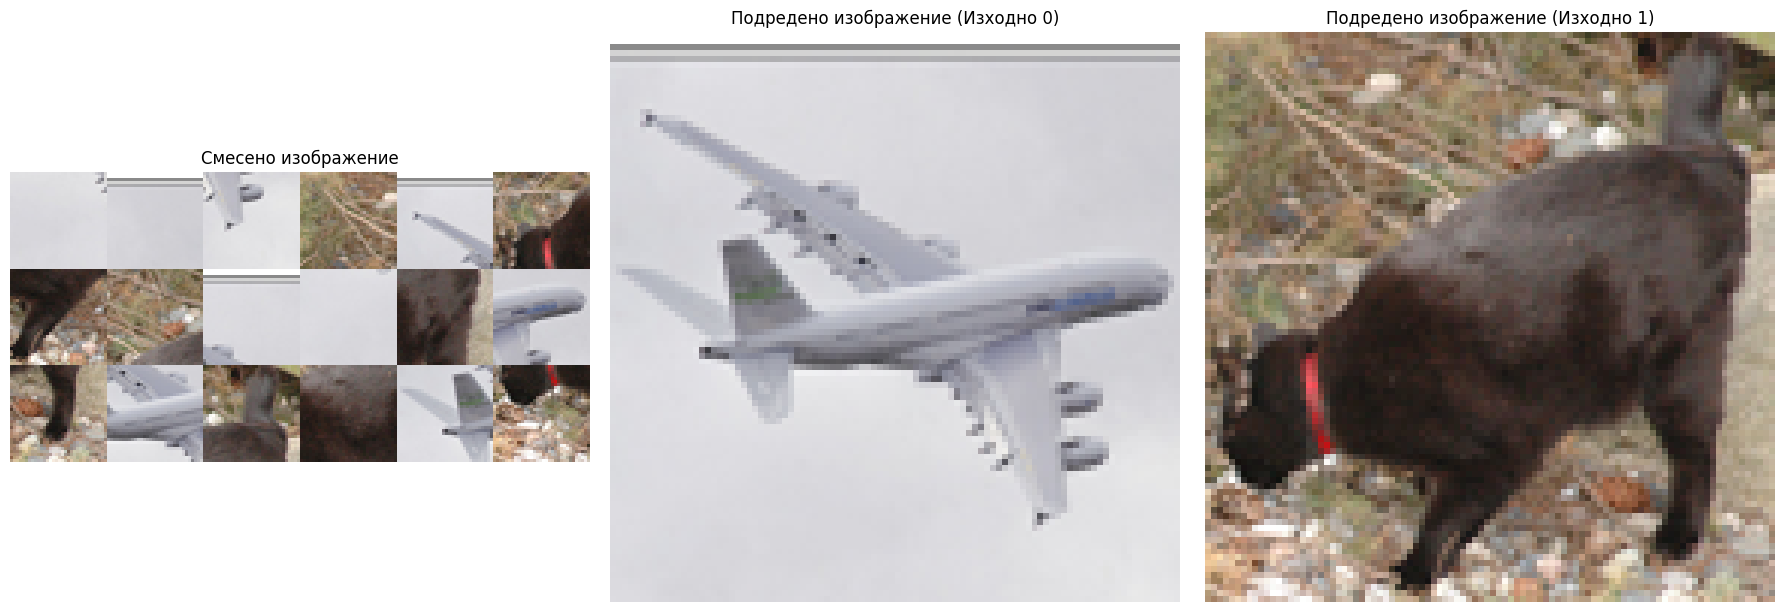

In [48]:
train_dataset = MixedSTL10Dataset(root_dir=args.data_dir, split="train")
visualize_mixed_and_reordered(train_dataset, 3)

In [16]:
#BEST
train_model(args)

Using device: cuda
Training set size: 5000
Validation set size: 500
Model architecture:
TileClassifier(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

TileClassifier(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [18]:
# Тестово множество и зареждане
test_dataset = MixedSTL10Dataset(root_dir=args.data_dir, split="test") # Use val as test data for this example
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=4)

device = get_device()

# Зареди най-добрия модел
best_model_path = os.path.join(args.output_dir, "best_model.pth")
checkpoint = torch.load(best_model_path)
model, _, _, _, _ = setup_training_components(device) # Re-initialize model architecture
model.load_state_dict(checkpoint['model_state_dict'])

# Създай файл с финални предсказания върху теста
create_submission_file(model, test_loader, device)

Using device: cuda
Model architecture:
TileClassifier(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0